In [ ]:
import joblib
import numpy as np
import pandas as pd

latents = joblib.load("outputs/muraro_latents.joblib")
pred_labels = joblib.load("outputs/muraro_pred_label.joblib")

latents = np.asarray(latents)
pred_labels = np.asarray(pred_labels)

print("Latents raw:", latents.shape)
print("Labels raw:", pred_labels.shape)

# Dernier état sauvegardé
latent_last = latents[-1]  # (2122, 5, 32)
labels_final = pred_labels[-1]  # (2122,)

# Transformer en matrice cellules × features
latent_matrix = latent_last.reshape(latent_last.shape[0], -1)

print("Latent matrix:", latent_matrix.shape)
print("Final labels:", labels_final.shape)
print("Clusters:", np.unique(labels_final))

assert latent_matrix.shape[0] == labels_final.shape[0]


Latents raw: (10, 2122, 5, 32)
Labels raw: (270, 2122)
Latent matrix: (2122, 160)
Final labels: (2122,)
Clusters: [0 1 2 3 4 5 6]


In [ ]:
results = pd.DataFrame(
    {"cell_index": np.arange(labels_final.shape[0]), "scMUG_cluster": labels_final}
)

results.head()

,cell_index,scMUG_cluster
0,0,1
1,1,6
2,2,1
3,3,5
4,4,3


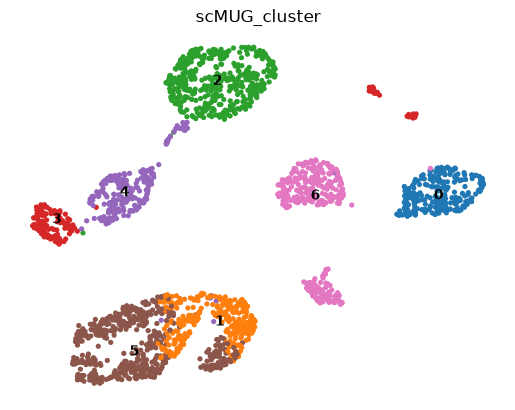

In [ ]:
assert adata_scMUG.n_obs == latent_matrix.shape[0]

adata_scMUG.obsm["X_scMUG"] = latent_matrix
adata_scMUG.obs["scMUG_cluster"] = pd.Categorical(labels_final.astype(str))

sc.pp.neighbors(adata_scMUG, use_rep="X_scMUG")
sc.tl.umap(adata_scMUG)

sc.pl.umap(adata_scMUG, color=["scMUG_cluster"], frameon=False, legend_loc="on data")